In [1]:
# General packages.
import os
import warnings
import random
import torch
import glob
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from nltk import word_tokenize

from textblob import TextBlob

# Add tools path for additional Python code. 
import sys
sys.path.append("./tools/")

# Text processing
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [2]:
# Random States
def set_random_states(random_state):
    # Set various random seeds.
    np.random.seed(random_state)
    random.seed(random_state)
    torch.manual_seed(random_state)
    torch.cuda.manual_seed_all(random_state)
    os.environ["PYTHONHASHSEED"] = str(random_state)
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    return random_state
RANDOM_STATE = set_random_states(1618)
# Ignore UserWarnings.
warnings.filterwarnings("ignore", category=UserWarning)
# Initialize constant variables.
INPUT_FOLDER_REAL = 'data'
INPUT_FOLDER_SYNTHETIC = 'dataSynthetic'

In [3]:
stop_words = set(stopwords.words("english"))

In [4]:
# Make function to remove punctuation, make lowercase, remove stopwords, punctuation, remove documents with less than or equal to 1 token.
def preprocessing(notes, min_words=1):
    cleaned_notes = []

    for note in notes:
        tokens = word_tokenize(note, language='english')
        tokens = [token.lower() for token in tokens]
        tokens = [token for token in tokens if token.isalpha() and token not in stop_words]

        if len(tokens) >= min_words:
            cleaned_notes.append(" ".join(tokens))

    return cleaned_notes

In [5]:
# Process all T1 files (this can be adjusted later for T2 also).
real_text_notes = {}
for folder in os.listdir(f'./{INPUT_FOLDER_REAL}/'):
    if '.' not in folder:
        for sub_folder in os.listdir(f'./{INPUT_FOLDER_REAL}/{folder}'):
            if '.' not in sub_folder and 'T1' in sub_folder:
                for sub_sub_folder in os.listdir(f'./{INPUT_FOLDER_REAL}/{folder}/{sub_folder}'):
                    if '.' not in sub_sub_folder:
                        carer_notes, carer_files = [], glob.glob(f'./{INPUT_FOLDER_REAL}/{folder}/{sub_folder}/{sub_sub_folder}/carerNotes*.xlsx')
                        nurse_notes, nurse_files = [], glob.glob(f'./{INPUT_FOLDER_REAL}/{folder}/{sub_folder}/{sub_sub_folder}/dailyNurseNotes*.xlsx')
                        multi_notes, multi_files = [], glob.glob(f'./{INPUT_FOLDER_REAL}/{folder}/{sub_folder}/{sub_sub_folder}/multiDisciplinaryNotes*.xlsx')
                        for carer_file in carer_files:
                            temp_df = pd.read_excel(f'{carer_file}', skiprows= 3, header=[0, 1])
                            carer_notes.extend([temp_note[0] for temp_note in temp_df['Activity'].dropna().values.tolist()])
                        for nurse_file in nurse_files:
                            temp_df = pd.read_excel(f'{nurse_file}')
                            nurse_notes.extend(temp_df['Note'].dropna().values.tolist())
                        for multi_file in multi_files:
                            temp_df = pd.read_excel(f'{multi_file}')
                            multi_notes.extend(temp_df['Note'].dropna().values.tolist())
                        real_text_notes[sub_sub_folder.split(' ')[0]] = {'Carer Notes': preprocessing(carer_notes), 'Multidisciplinary Notes': preprocessing(multi_notes), 'Nurse Notes': preprocessing(nurse_notes)}

In [6]:
synthetic_text_notes = []
for file in os.listdir(f"./{INPUT_FOLDER_SYNTHETIC}/"):
    if '.csv' in file:
        synthetic_text_notes.extend(preprocessing(pd.read_csv(f"./{INPUT_FOLDER_SYNTHETIC}/{file}")['report'].values.tolist()))

In [13]:
analysis_dict = {
    'Data Type':[], 
    'Number of Texts':[], 
    'Total Words':[],
    'Unique Words / Vocab Size':[],
    'Text Lengths':[],
    'Average Text Length':[],
    'Text Word Counts':[],
    'Average Text Word Count':[],
    'Shortest Text Word Count':[],
    'Longest Text Word Count':[],
    'Most Common n-grams':[],
    'Most Common Word':[],
    'Sentiments':[],
    'Subjectivities':[]
    } 

In [14]:
def text_statistics(texts, data_type, analysis_dict):
    lengths = [len(t) for t in texts]
    all_tokens = [word_tokenize(t) for t in texts]
    word_counts = [len(tok) for tok in all_tokens]

    all_words = [w for tok in all_tokens for w in tok]
    vocab = set(all_words)

    all_words = [w for t in texts for w in word_tokenize(t)]
    counter = Counter(all_words)

    ngrams = []
    for tokens in all_tokens:
        ngrams += zip(*[tokens[i:] for i in range(2)])

    counter_ngrams = Counter(ngrams)

    polarities = []
    subjectivities = []
    for i, text in enumerate(texts):
        temp_text_blob = TextBlob(text)
        polarities.append(temp_text_blob.sentiment.polarity)
        subjectivities.append(temp_text_blob.sentiment.subjectivity)

    analysis_dict['Data Type'].append(data_type)
    analysis_dict['Number of Texts'].append(len(texts))
    analysis_dict['Total Words'].append(len(all_words))
    analysis_dict['Unique Words / Vocab Size'].append(len(vocab))
    analysis_dict['Text Lengths'].append(lengths)
    analysis_dict['Average Text Length'].append(sum(lengths)/len(lengths))
    analysis_dict['Text Word Counts'].append(word_counts)
    analysis_dict['Average Text Word Count'].append(sum(word_counts)/len(word_counts))
    analysis_dict['Shortest Text Word Count'].append(min(word_counts))
    analysis_dict['Longest Text Word Count'].append(max(word_counts))
    analysis_dict['Most Common n-grams'].append(counter_ngrams.most_common(10))
    analysis_dict['Most Common Word'].append(counter.most_common(10))
    analysis_dict['Sentiments'].append(polarities)
    analysis_dict['Subjectivities'].append(subjectivities)
    
    return analysis_dict


In [15]:
def plot_word_distribution(texts, file_name = ''):
    word_counts = [len(word_tokenize(t)) for t in texts]

    plt.figure()
    plt.hist(word_counts, bins=20)
    plt.xlabel("Words per Text")
    plt.ylabel("Frequency")
    plt.tight_layout()
    # if file_name != '':
    #     plt.savefig(f"./{IMAGE_OUTPUT_FOLDER}/{file_name}WordDistribution.png", bbox_inches='tight', dpi=300)
    plt.show()

In [16]:
def plot_top_words(texts, n, file_name = ''):
    all_words = [w for t in texts for w in word_tokenize(t)]
    counter = Counter(all_words)
    common = counter.most_common(n)

    words = [w for w, _ in common]
    freqs = [f for _, f in common]

    plt.figure()
    plt.bar(words, freqs)
    plt.xticks(rotation=45)
    plt.ylabel("Frequency")
    plt.tight_layout()
    # if file_name != '':
    #     plt.savefig(f"./{IMAGE_OUTPUT_FOLDER}/{file_name}TopWords.png", bbox_inches='tight', dpi=300)
    plt.show()

In [17]:
real_text_notes_together = []
for patient, texts in real_text_notes.items():
    real_text_notes_together.extend(texts['Nurse Notes'])

-----------Real Data-----------


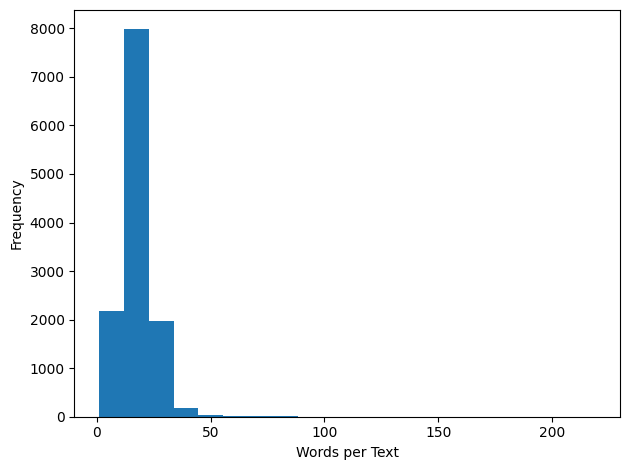

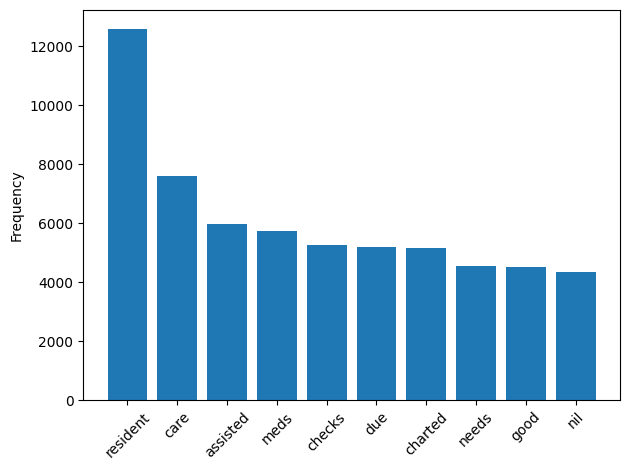

-----------Synthetic Data-----------


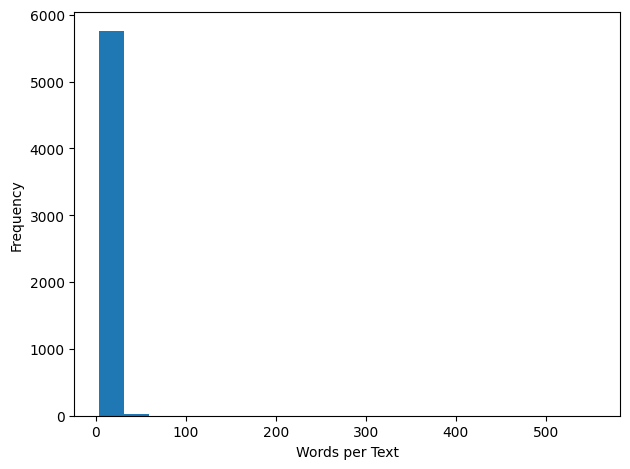

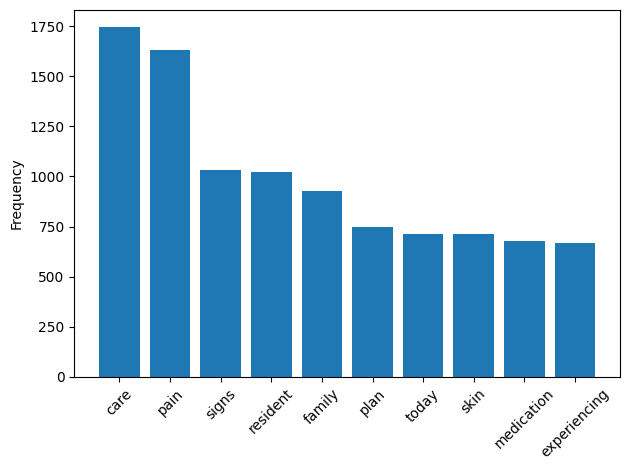

In [18]:
for key, texts in {'Real Data': real_text_notes_together, 'Synthetic Data': synthetic_text_notes}.items():
    print(f"-----------{key}-----------")
    analysis_dict = text_statistics(texts, key, analysis_dict)
    plot_word_distribution(texts)
    plot_top_words(texts, 10)

In [19]:
analysis_df = pd.DataFrame(analysis_dict)
analysis_df

,Data Type,Number of Texts,Total Words,Unique Words / Vocab Size,Text Lengths,Average Text Length,Text Word Counts,Average Text Word Count,Shortest Text Word Count,Longest Text Word Count,Most Common n-grams,Most Common Word,Sentiments,Subjectivities
0,Real Data,12407,216630,3920,"[122, 94, 126, 77, 55, 96, 132, 131, 119, 74, ...",123.365761,"[16, 14, 19, 11, 9, 16, 18, 19, 17, 11, 17, 17...",17.460305,1,219,"[((due, meds), 3643), ((care, needs), 3198), (...","[(resident, 12603), (care, 7600), (assisted, 5...","[0.06875, 0.0, 0.2875, 0.3666666666666667, 0.3...","[0.36875, 0.0, 0.48750000000000004, 0.63333333..."
1,Synthetic Data,5783,82739,3504,"[123, 143, 141, 141, 131, 119, 135, 125, 155, ...",113.482449,"[16, 18, 16, 17, 16, 15, 19, 16, 20, 17, 18, 1...",14.307280,4,555,"[((palliative, care), 585), ((care, plan), 577...","[(care, 1743), (pain, 1631), (signs, 1032), (r...","[-0.25, 0.0, -0.125, 0.4, -0.05000000000000001...","[0.25, 0.0, 0.825, 0.7, 0.48333333333333334, 0..."


1559

In [36]:
def histogram(index, column_name = 'Text Lengths'):
    bins = np.linspace(min(analysis_df[column_name][index]), max(analysis_df[column_name][index]), 100)
    counts, edges = np.histogram(analysis_df[column_name][index], bins=bins)

    plt.bar(edges[:-1], counts, width=np.diff(edges))
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.title(f"Binned {column_name} Distribution")
    plt.show()

Real Data


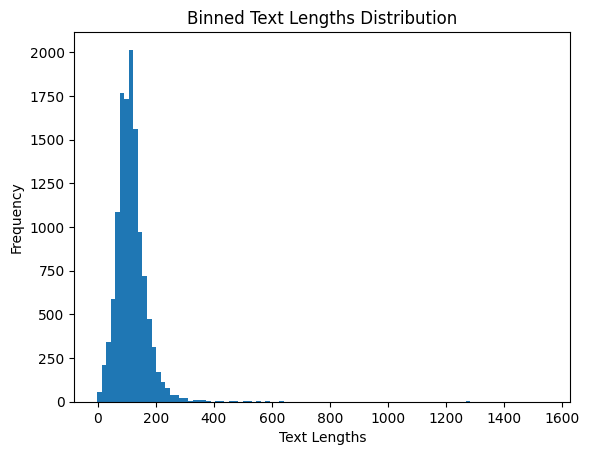

Synthetic Data


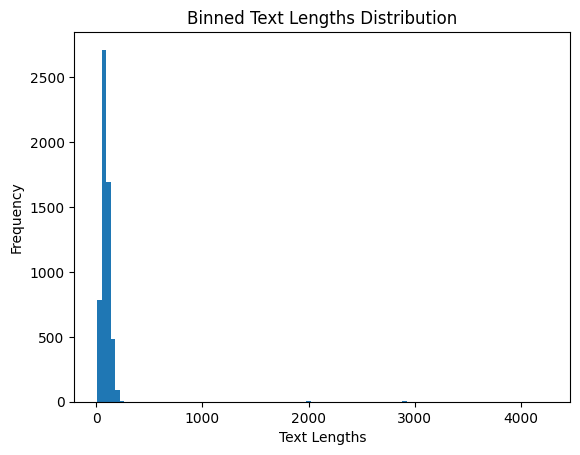

In [38]:
print(analysis_df['Data Type'][0])
histogram(0, column_name='Text Lengths')
print(analysis_df['Data Type'][1])
histogram(1, column_name='Text Lengths')

Real Data


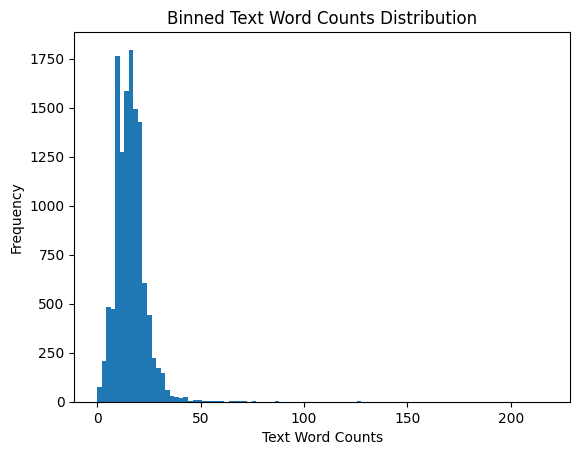

Synthetic Data


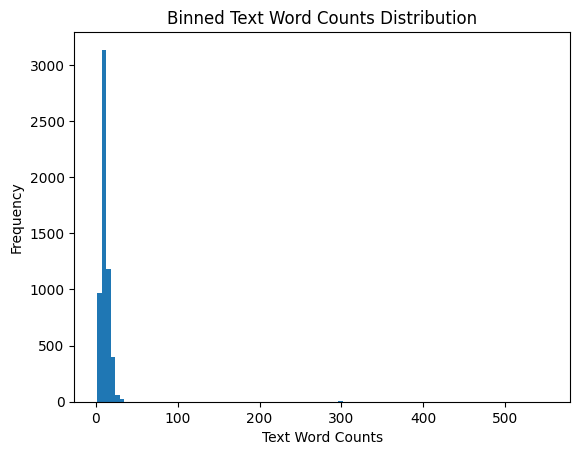

In [39]:
print(analysis_df['Data Type'][0])
histogram(0, column_name='Text Word Counts')
print(analysis_df['Data Type'][1])
histogram(1, column_name='Text Word Counts')